In [14]:
# 导入测试得到的数据
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_path = "/Users/ccg/Study/Mujoco/IL/musculoco_GAIL/experiments/12_torque_fidelity/runs/test_12_fidelity/torques.csv"

data = pd.read_csv(data_path)

# 取前100行数据进行分析
data = data.iloc[:100]
data

,episode,step,time,hip_flexion_r,hip_adduction_r,hip_rotation_r,knee_angle_r,ankle_angle_r,hip_flexion_l,hip_adduction_l,...,act:per_long_l,act:per_tert_l,act:ext_dig_l,act:ext_hal_l,act:ercspn_r,act:ercspn_l,act:intobl_r,act:intobl_l,act:extobl_r,act:extobl_l
0,0.0,0.0,0.01,16.213213,-6.446117,0.429018,-4.602737,11.570494,7.683752,-16.246752,...,0.146521,0.471073,0.466822,0.649520,0.649520,0.319922,0.649520,0.000000,0.649520,0.649520
1,0.0,1.0,0.02,16.045739,-11.218409,1.654849,9.663572,1.799779,25.672182,-15.849019,...,0.376020,0.438721,0.476247,0.816198,0.532142,0.321527,0.816198,0.000000,0.816198,0.816198
2,0.0,2.0,0.03,21.245588,-3.076447,0.146590,13.244758,2.466561,32.050406,-19.906177,...,0.363241,0.524209,0.430123,0.896753,0.483882,0.386316,0.896753,0.000000,0.705265,0.896753
3,0.0,3.0,0.04,22.273079,1.187650,-1.318587,13.040091,2.234373,30.843302,-25.052945,...,0.282940,0.690528,0.454236,0.940274,0.584633,0.431026,0.940274,0.000000,0.566296,0.940274
4,0.0,4.0,0.05,19.621386,1.898796,-1.509319,10.673026,1.219831,26.753658,-32.525932,...,0.226281,0.834763,0.446448,0.964930,0.721021,0.509674,0.964930,0.131520,0.448266,0.964930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,95.0,0.96,-35.880247,12.826679,-6.936302,-50.504446,-5.295666,-15.404783,-50.365028,...,0.986226,0.200406,0.003987,0.607307,0.988191,0.994054,1.000000,0.114134,0.083050,1.000000
96,0.0,96.0,0.97,-86.992130,21.906339,-8.188672,-79.710487,2.424891,5.883617,-42.822479,...,0.991789,0.164777,0.003511,0.438051,0.992956,0.996447,1.000000,0.096666,0.208642,1.000000
97,0.0,97.0,0.98,-94.356390,27.183781,-10.090312,-74.164452,-0.463168,37.811756,-19.104226,...,0.995097,0.137139,0.003092,0.333095,0.995792,0.903649,1.000000,0.082371,0.416500,1.000000
98,0.0,98.0,0.99,-83.176169,23.159751,-11.387119,-55.521827,2.042102,55.870490,0.177892,...,0.997069,0.115228,0.002724,0.262023,0.997484,0.761433,1.000000,0.070543,0.545356,1.000000


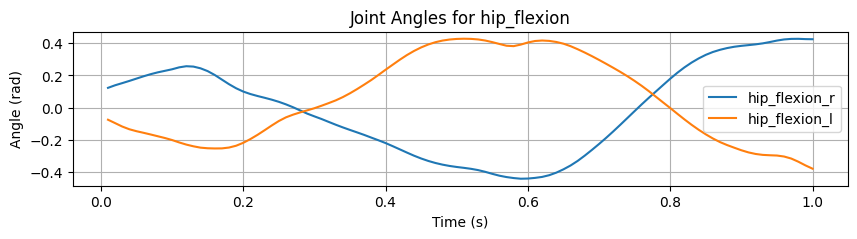

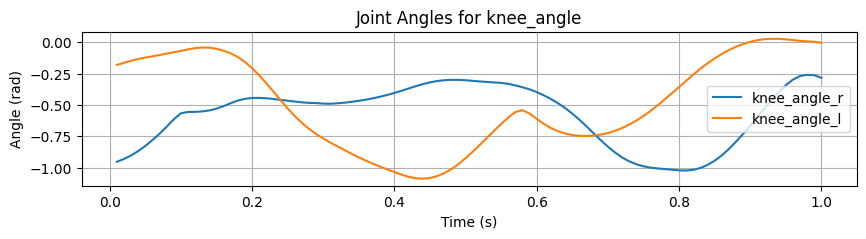

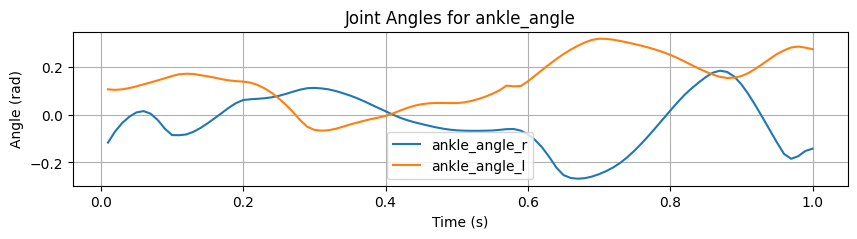

In [15]:
# 画出各个关节的角度曲线,在 CSV 中以 q:joint_name命名。左右腿的同一个关节的角度画在同一张图上
joint_names = ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r', 'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l']
for joint_name in ['hip_flexion', 'knee_angle', 'ankle_angle']:
    plt.figure(figsize=(10,2))
    plt.plot(data['time'], data[f'q:{joint_name}_r'], label=f'{joint_name}_r')
    plt.plot(data['time'], data[f'q:{joint_name}_l'], label=f'{joint_name}_l')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (rad)')
    plt.title(f'Joint Angles for {joint_name}')
    plt.legend()
    plt.grid()
    plt.show()

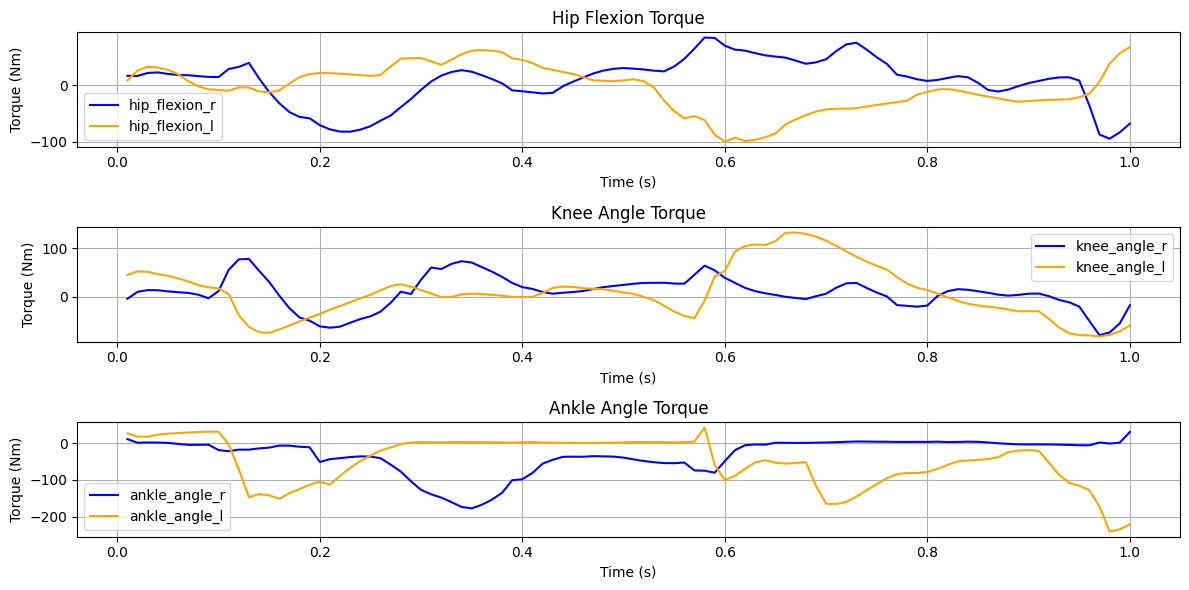

In [16]:
# 先画出各个关节的力矩曲线，左右画在同一张图上
# “hip_flexion_r” and “hip_flexion_l” on the same plot
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(data['time'], data['hip_flexion_r'], label='hip_flexion_r', color='blue')
plt.plot(data['time'], data['hip_flexion_l'], label='hip_flexion_l', color='orange')
plt.title('Hip Flexion Torque')
plt.xlabel('Time (s)')
plt.ylabel('Torque (Nm)')
plt.legend()
# 加上网格线
plt.grid()

# “knee_angle_r” and “knee_angle_l” on the same plot
plt.subplot(3, 1, 2)
plt.plot(data['time'], data['knee_angle_r'], label='knee_angle_r', color='blue')
plt.plot(data['time'], data['knee_angle_l'], label='knee_angle_l', color='orange')
plt.title('Knee Angle Torque')
plt.xlabel('Time (s)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.grid()

# “ankle_angle_r” and “ankle_angle_l” on the same plot
plt.subplot(3, 1, 3)
plt.plot(data['time'], data['ankle_angle_r'], label='ankle_angle_r', color='blue')
plt.plot(data['time'], data['ankle_angle_l'], label='ankle_angle_l', color='orange')
plt.title('Ankle Angle Torque')
plt.xlabel('Time (s)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [17]:
# 打印出所有控制信号的名字
# print("Control Signal Names:")
# for col in data.columns:
#     if 'ctrl' in col:
#         print(col)
# for col in data.columns:
#     if 'act' in col:
#         print(col)
# Control Signal Names:
# ctrl:glut_med1_r
# ctrl:glut_med2_r
# ctrl:glut_med3_r
# ctrl:glut_min1_r
# ctrl:glut_min2_r
# ctrl:glut_min3_r
# ctrl:semimem_r
# ctrl:semiten_r
# ctrl:bifemlh_r
# ctrl:bifemsh_r
# ctrl:sar_r
# ctrl:add_long_r
# ctrl:add_brev_r
# ctrl:add_mag1_r
# ctrl:add_mag2_r
# ctrl:add_mag3_r
# ctrl:tfl_r
# ctrl:pect_r
# ctrl:grac_r
# ctrl:glut_max1_r
# ctrl:glut_max2_r
# ctrl:glut_max3_r
# ctrl:iliacus_r
# ctrl:psoas_r
# ctrl:quad_fem_r
# ctrl:gem_r
# ctrl:peri_r
# ctrl:rect_fem_r
# ctrl:vas_med_r
# ctrl:vas_int_r
# ctrl:vas_lat_r
# ctrl:med_gas_r
# ctrl:lat_gas_r
# ctrl:soleus_r
# ctrl:tib_post_r
# ctrl:flex_dig_r
# ctrl:flex_hal_r
# ctrl:tib_ant_r
# ctrl:per_brev_r
# ctrl:per_long_r
# ctrl:per_tert_r
# ctrl:ext_dig_r
# ctrl:ext_hal_r
# ctrl:glut_med1_l
# ctrl:glut_med2_l
# ctrl:glut_med3_l
# ctrl:glut_min1_l
# ctrl:glut_min2_l
# ctrl:glut_min3_l
# ctrl:semimem_l
# ctrl:semiten_l
# ctrl:bifemlh_l
# ctrl:bifemsh_l
# ctrl:sar_l
# ctrl:add_long_l
# ctrl:add_brev_l
# ctrl:add_mag1_l
# ctrl:add_mag2_l
# ctrl:add_mag3_l
# ctrl:tfl_l
# ctrl:pect_l
# ctrl:grac_l
# ctrl:glut_max1_l
# ctrl:glut_max2_l
# ctrl:glut_max3_l
# ctrl:iliacus_l
# ctrl:psoas_l
# ctrl:quad_fem_l
# ctrl:gem_l
# ctrl:peri_l
# ctrl:rect_fem_l
# ctrl:vas_med_l
# ctrl:vas_int_l
# ctrl:vas_lat_l
# ctrl:med_gas_l
# ctrl:lat_gas_l
# ctrl:soleus_l
# ctrl:tib_post_l
# ctrl:flex_dig_l
# ctrl:flex_hal_l
# ctrl:tib_ant_l
# ctrl:per_brev_l
# ctrl:per_long_l
# ctrl:per_tert_l
# ctrl:ext_dig_l
# ctrl:ext_hal_l
# ctrl:ercspn_r
# ctrl:ercspn_l
# ctrl:intobl_r
# ctrl:intobl_l
# ctrl:extobl_r
# ctrl:extobl_l


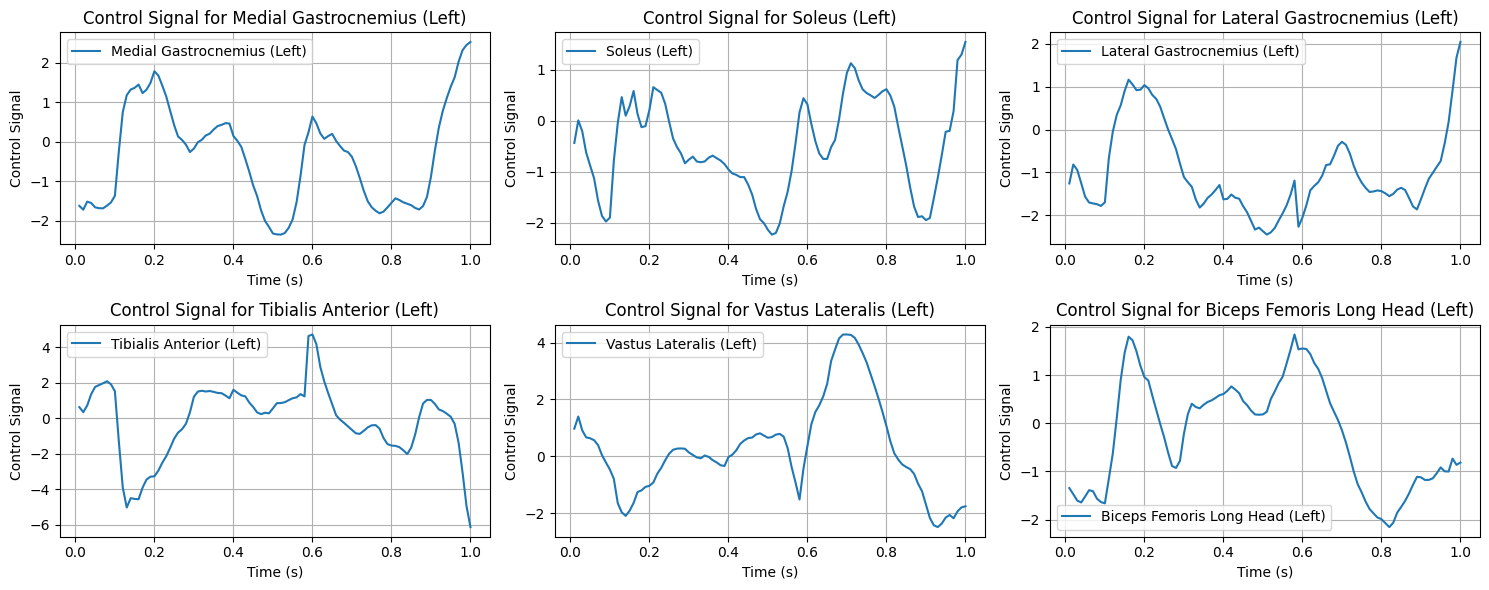

In [18]:
# 画出右腿最主要肌肉控制信号的变化曲线，
major_muscles = [
    'ctrl:med_gas_l', # 腓肠肌内侧头
    'ctrl:soleus_l', # 左腿比目鱼肌
    'ctrl:lat_gas_l', # 腓肠肌外侧头
    'ctrl:tib_ant_l', # 左腿胫前肌
    'ctrl:vas_lat_l', # 左腿外侧股四头肌
    'ctrl:bifemlh_l'  # 
]
muscle_labels = {
    'ctrl:med_gas_l': 'Medial Gastrocnemius (Left)',
    'ctrl:lat_gas_l': 'Lateral Gastrocnemius (Left)',
    'ctrl:soleus_l': 'Soleus (Left)',
    'ctrl:tib_ant_l': 'Tibialis Anterior (Left)',
    'ctrl:vas_lat_l': 'Vastus Lateralis (Left)',
    'ctrl:bifemlh_l': 'Biceps Femoris Long Head (Left)'
}
# 画图
plt.figure(figsize=(15, 6))
for muscle in major_muscles:
    plt.subplot(2, 3, major_muscles.index(muscle) + 1)
    plt.plot(data['time'], data[muscle], label=muscle_labels[muscle])
    plt.title(f'Control Signal for {muscle_labels[muscle]}')
    plt.xlabel('Time (s)')
    plt.ylabel('Control Signal')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

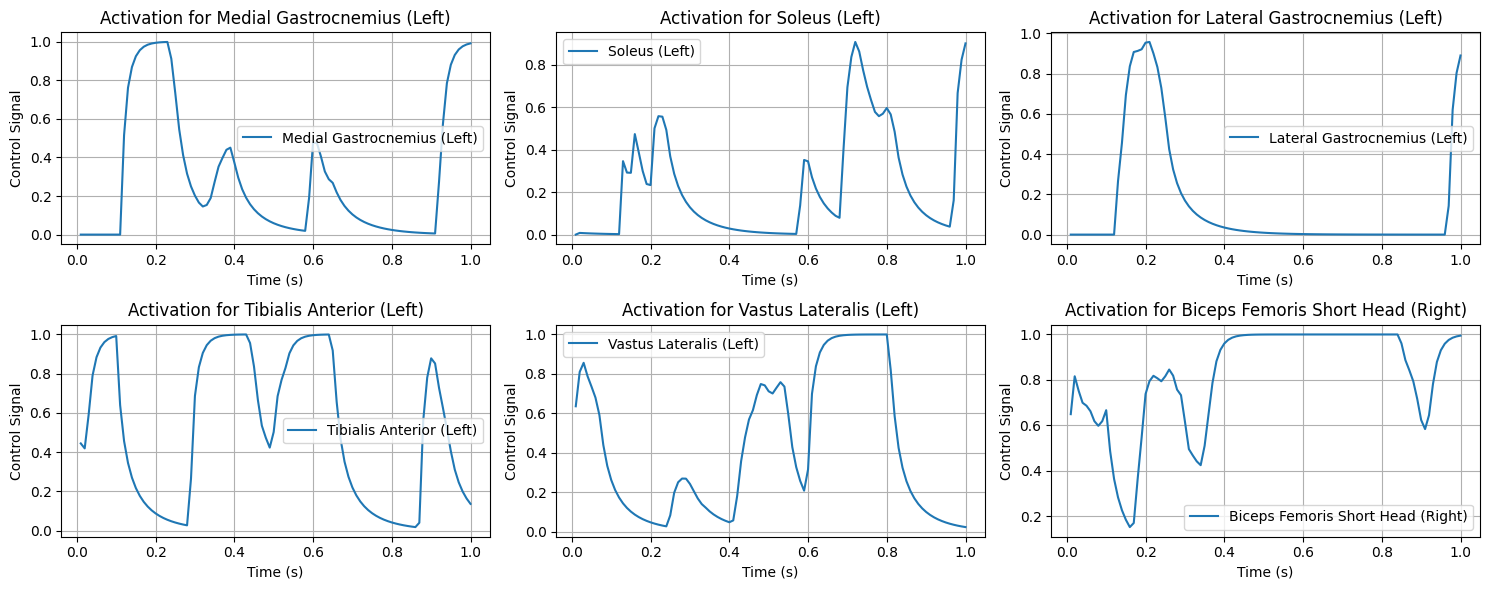

In [19]:
# 画出右腿最主要肌肉控制信号的变化曲线，
major_muscles = [
    'act:med_gas_l', # 腓肠肌内侧头
    'act:soleus_l', # 左腿比目鱼肌
    'act:lat_gas_l', # 腓肠肌外侧头
    'act:tib_ant_l', # 左腿胫前肌
    'act:vas_lat_l', # 左腿外侧股四头肌
    'act:bifemsh_r'  # 左侧腿股二头肌短头
]
muscle_labels = {
    'act:med_gas_l': 'Medial Gastrocnemius (Left)',
    'act:lat_gas_l': 'Lateral Gastrocnemius (Left)',
    'act:soleus_l': 'Soleus (Left)',
    'act:tib_ant_l': 'Tibialis Anterior (Left)',
    'act:vas_lat_l': 'Vastus Lateralis (Left)',
    'act:bifemsh_r': 'Biceps Femoris Short Head (Right)'
}
# 画图
plt.figure(figsize=(15, 6))
for muscle in major_muscles:
    plt.subplot(2, 3, major_muscles.index(muscle) + 1)
    plt.plot(data['time'], data[muscle], label=muscle_labels[muscle])
    plt.title(f'Activation for {muscle_labels[muscle]}')
    plt.xlabel('Time (s)')
    plt.ylabel('Control Signal')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

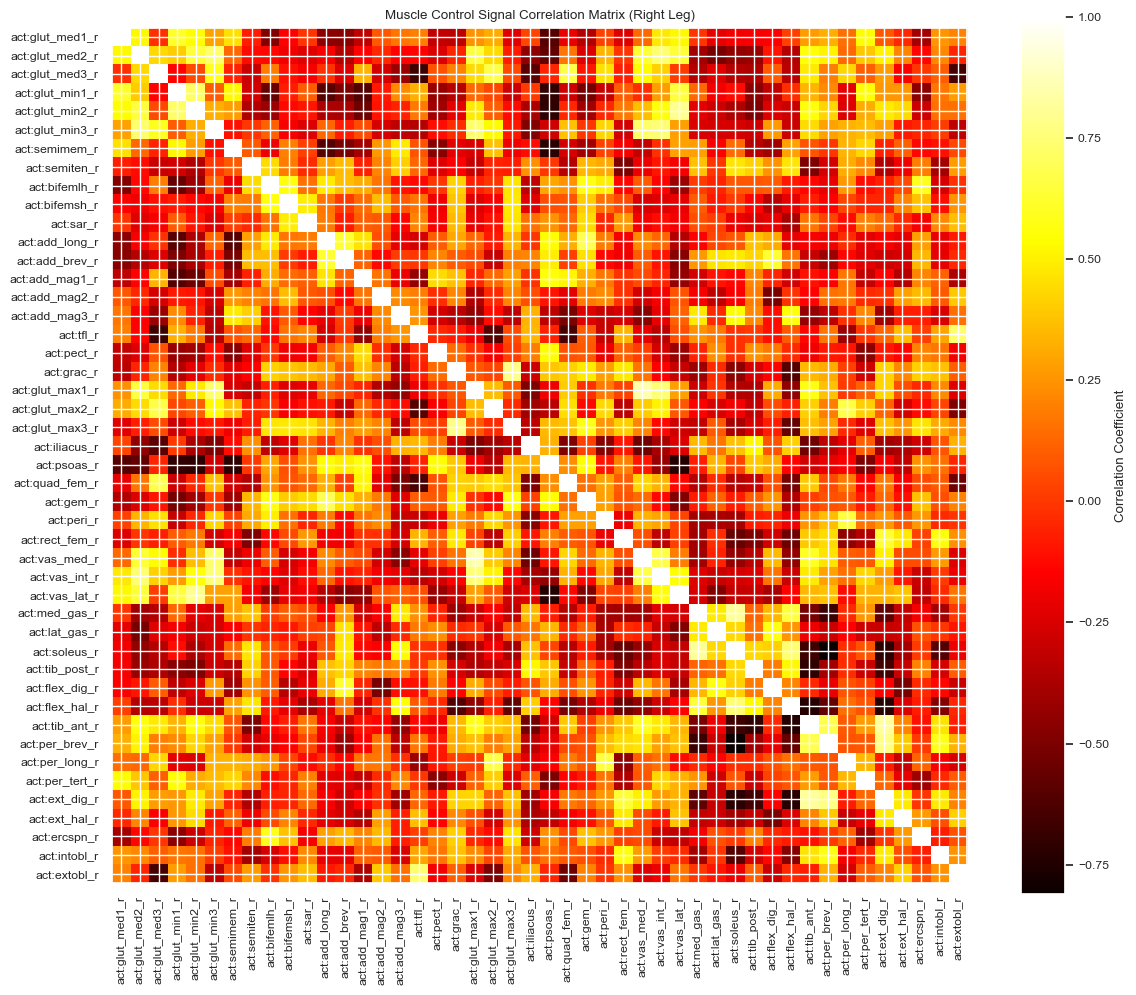

In [78]:
# 分析肌肉的共激活情况，以右腿为例
from itertools import combinations
muscle_act = [col for col in data.columns if col.startswith('act:') and col.endswith('_r')]
correlation_matrix = pd.DataFrame(index=muscle_act, columns=muscle_act)
for muscle1, muscle2 in combinations(muscle_act, 2):
    correlation = data[muscle1].corr(data[muscle2])
    correlation_matrix.loc[muscle1, muscle2] = correlation
    correlation_matrix.loc[muscle2, muscle1] = correlation
# 填充对角线为1
for muscle in muscle_act:
    correlation_matrix.loc[muscle, muscle] = 1.0
correlation_matrix = correlation_matrix.astype(float)
# 画出热力图
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='hot', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')
plt.xticks(ticks=np.arange(len(muscle_act)), labels=muscle_act, rotation=90)
plt.yticks(ticks=np.arange(len(muscle_act)), labels=muscle_act)
plt.title('Muscle Control Signal Correlation Matrix (Right Leg)')
plt.tight_layout()
plt.show()  

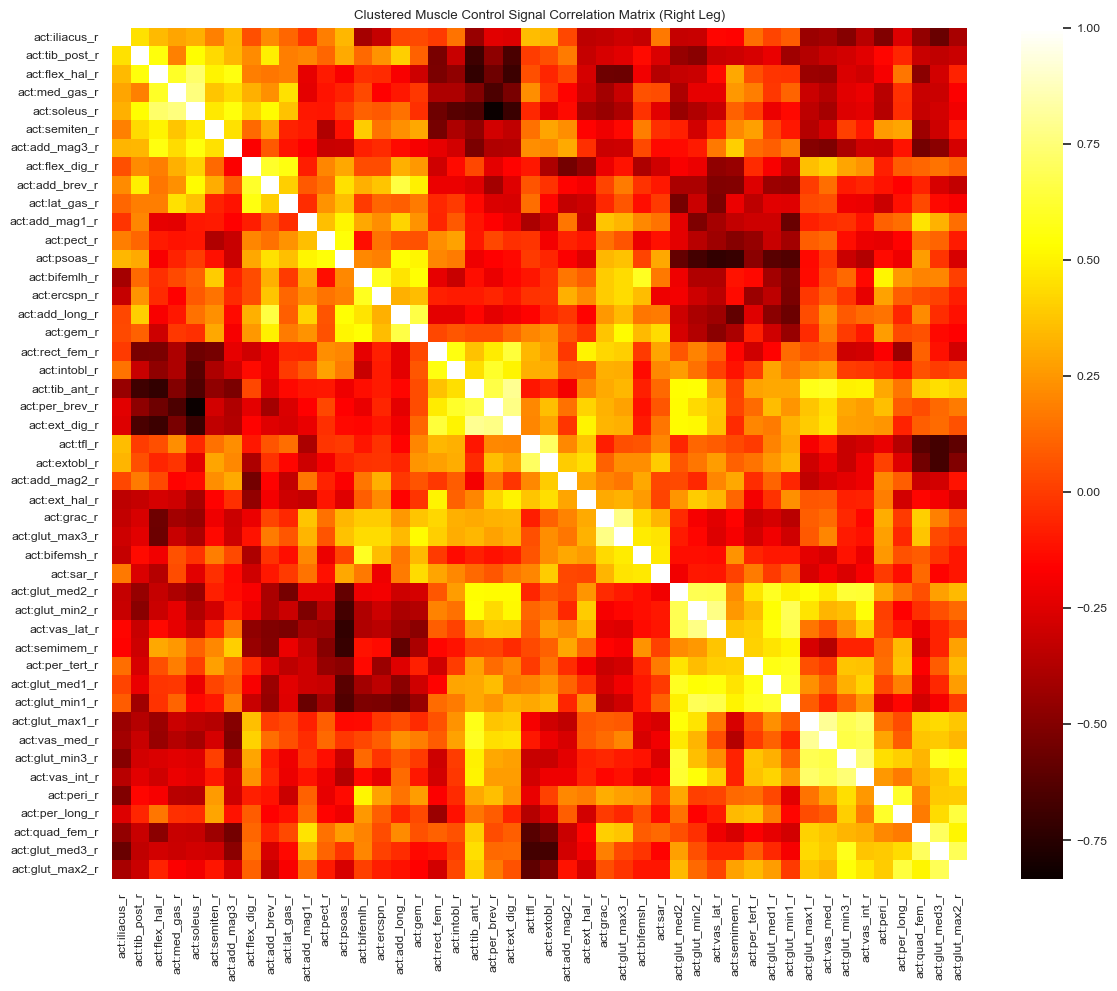

In [71]:
# 先把肌肉聚类后再绘制热力图
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
# 层次聚类
Z = linkage(correlation_matrix, method='ward')
# 获取聚类后的顺序
dendro = dendrogram(Z, no_plot=True)
ordered_indices = leaves_list(Z)
ordered_muscles = [muscle_act[i] for i in ordered_indices]
# 重排相关矩阵
ordered_correlation_matrix = correlation_matrix.loc[ordered_muscles, ordered_muscles]
# 画出热力图
plt.figure(figsize=(12, 10))
# 使用seaborn绘制更美观的热力图，颜色分层更显著,不使用hot或viridis，使用颜色尽可能多的热力图形式

sns.set(font_scale=0.8)
sns.heatmap(ordered_correlation_matrix, cmap='hot', annot=False)
plt.title('Clustered Muscle Control Signal Correlation Matrix (Right Leg)')
plt.tight_layout()
plt.show()


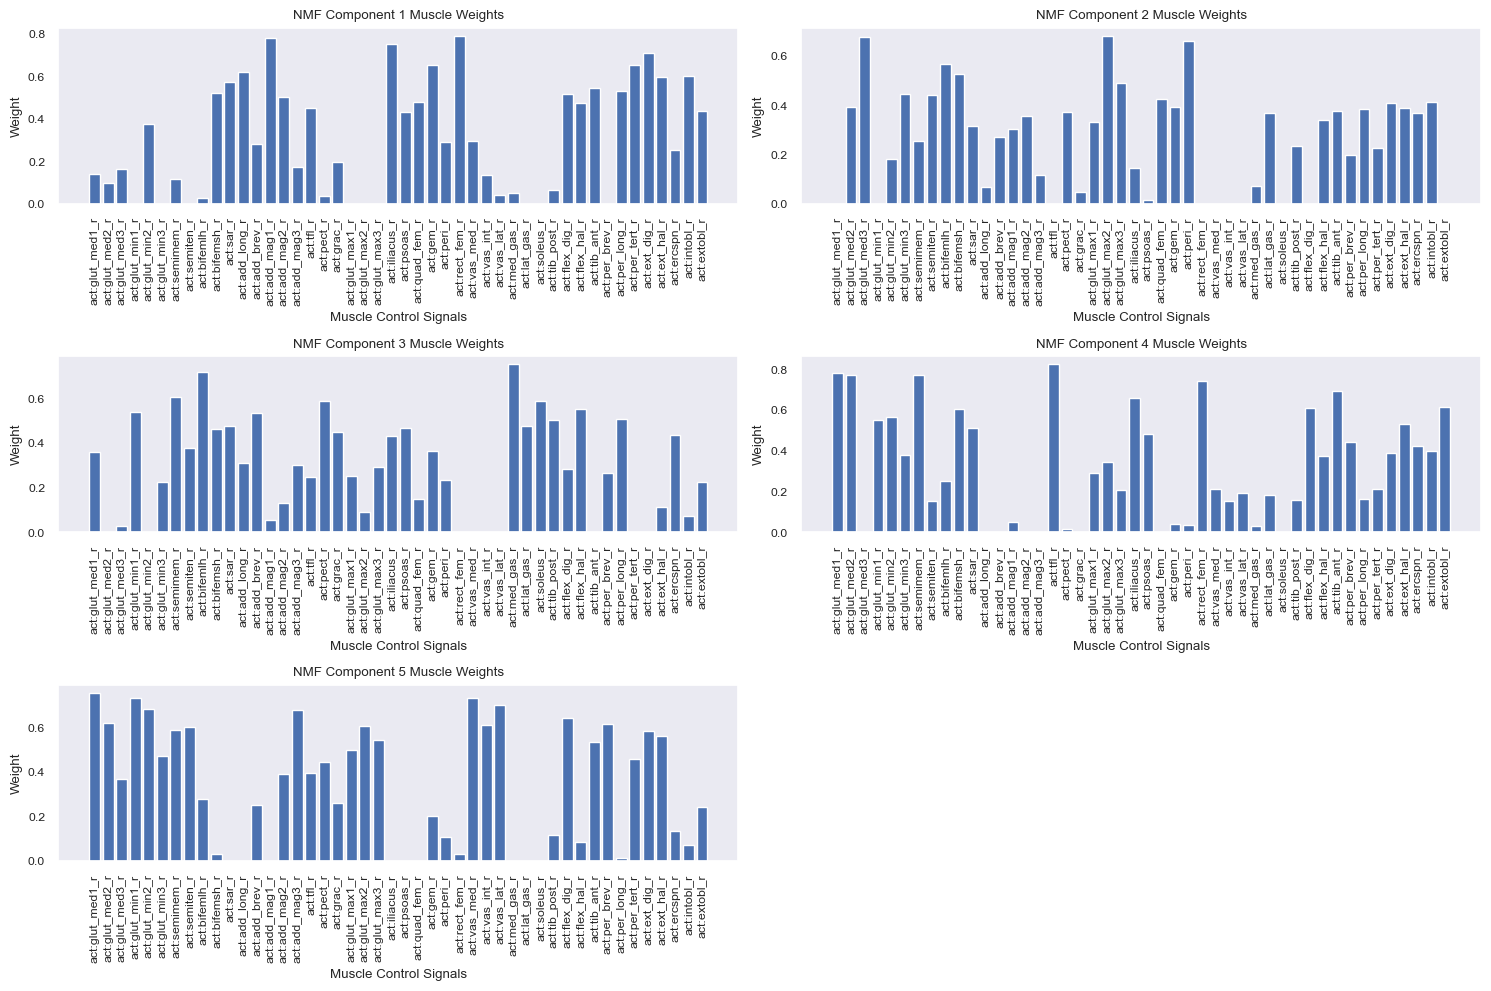

In [10]:
# 使用NMF进行肌肉控制信号的降维分析
from sklearn.decomposition import NMF
# 提取右腿肌肉控制信号数据
right_leg_data = data[muscle_act].values
# 使用NMF进行降维，设定成分数为5
nmf_model = NMF(n_components=5, init='random', random_state=0)
W = nmf_model.fit_transform(right_leg_data)
H = nmf_model.components_
# 画出每个成分的肌肉权重
plt.figure(figsize=(15, 10))
for i in range(H.shape[0]):
    plt.subplot(3, 2, i + 1)
    plt.bar(muscle_act, H[i])
    plt.title(f'NMF Component {i + 1} Muscle Weights')
    plt.xlabel('Muscle Control Signals')
    plt.ylabel('Weight')
    plt.xticks(rotation=90)
    plt.grid()
plt.tight_layout()
plt.show()